# **Analiza zdrowia psychicznego nastolatków z wykorzystaniem Machine Learning**

Celem projektu jest analiza danych dotyczących zdrowia psychicznego nastolatków oraz przewidywanie występowania depresji przy użyciu modeli uczenia maszynowego.

W projekcie przeanalizowano zależności pomiędzy:
- poziomem stresu,
- poziomem lęku,
- długością snu,
- korzystaniem z platform społecznościowych,
a występowaniem depresji.

Do budowy modeli wykorzystano:
- Logistic Regression
- Random Forest Classifier

In [47]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

#Pobieranie zbioru danych

In [48]:
!wget -O teen_mental_health.csv "https://raw.githubusercontent.com/rrawmann/Projekt_programowanie_Raman_Shlykau/refs/heads/main/Teen_Mental_Health_Dataset.csv"

--2026-06-07 15:24:59--  https://raw.githubusercontent.com/rrawmann/Projekt_programowanie_Raman_Shlykau/refs/heads/main/Teen_Mental_Health_Dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 62496 (61K) [text/plain]
Saving to: ‘teen_mental_health.csv’

teen_mental_health. 100%[===================>]  61.03K  --.-KB/s    in 0.01s   

2026-06-07 15:24:59 (4.33 MB/s) - ‘teen_mental_health.csv’ saved [62496/62496]



# Wczytanie zbioru danych

In [49]:
df = pd.read_csv("teen_mental_health.csv")

# Wstępna analiza danych

Na początku sprawdzono strukturę danych, liczbę kolumn oraz podstawowe statystyki opisowe.

In [50]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


# Statystyki opisowe danych

In [52]:
display(df.describe())

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


Statystyki opisowe pozwalają lepiej zrozumieć rozkład danych numerycznych, takie jak średnie wartości, odchylenia standardowe oraz wartości minimalne i maksymalne.

In [53]:
df.isnull().sum()

,0
age,0
gender,0
daily_social_media_hours,0
platform_usage,0
sleep_hours,0
screen_time_before_sleep,0
academic_performance,0
physical_activity,0
social_interaction_level,0
stress_level,0


In [54]:
df.nunique()

,0
age,7
gender,2
daily_social_media_hours,71
platform_usage,3
sleep_hours,51
screen_time_before_sleep,26
academic_performance,201
physical_activity,21
social_interaction_level,3
stress_level,10


W zbiorze danych nie występują brakujące wartości, dzięki czemu nie było konieczności usuwania rekordów ani dodatkowego czyszczenia danych.

# Analiza zmiennej docelowej

Sprawdzono rozkład zmiennej `depression_label`, która określa występowanie depresji.

In [55]:
df["depression_label"].value_counts()

,count
depression_label,
0,1169
1,31


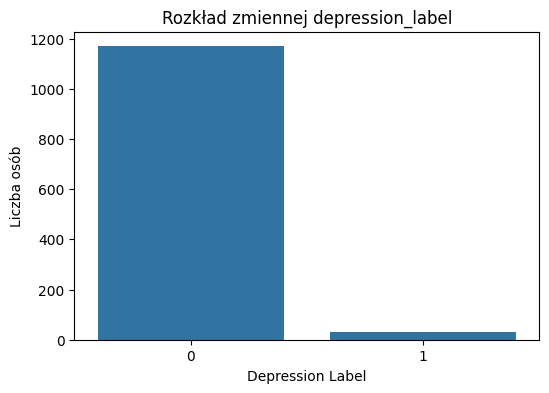

In [56]:
plt.figure(figsize=(6,4))

sns.countplot(x="depression_label", data=df)

plt.title("Rozkład zmiennej depression_label")

plt.xlabel("Depression Label")
plt.ylabel("Liczba osób")

plt.show()

Zbiór danych jest mocno niezbalansowany — większość obserwacji należy do klasy 0 (brak depresji).

Może to wpływać na działanie modeli uczenia maszynowego, dlatego w projekcie wykorzystano parametr `class_weight="balanced"`.

# Analiza zależności pomiędzy stresem a depresją

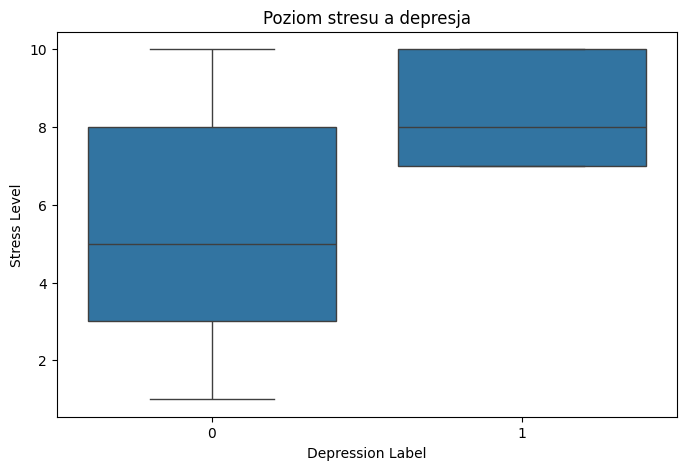

In [57]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="depression_label",
    y="stress_level",
    data=df
)

plt.title("Poziom stresu a depresja")

plt.xlabel("Depression Label")
plt.ylabel("Stress Level")

plt.show()

Osoby z depresją osiągają wyższe wartości poziomu stresu niż osoby bez depresji.

Może to sugerować istotny związek pomiędzy stresem a występowaniem depresji.

# Analiza zależności pomiędzy snem a depresją

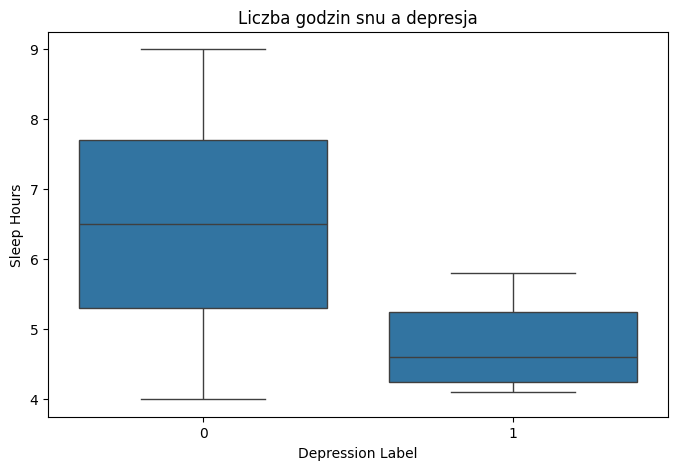

In [58]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="depression_label",
    y="sleep_hours",
    data=df
)

plt.title("Liczba godzin snu a depresja")

plt.xlabel("Depression Label")
plt.ylabel("Sleep Hours")

plt.show()

Osoby z depresją śpią średnio mniej godzin niż osoby bez depresji.

Może to wskazywać na zależność pomiędzy zaburzeniami snu a depresją.

# Analiza zależności pomiędzy poziomem lęku a depresją

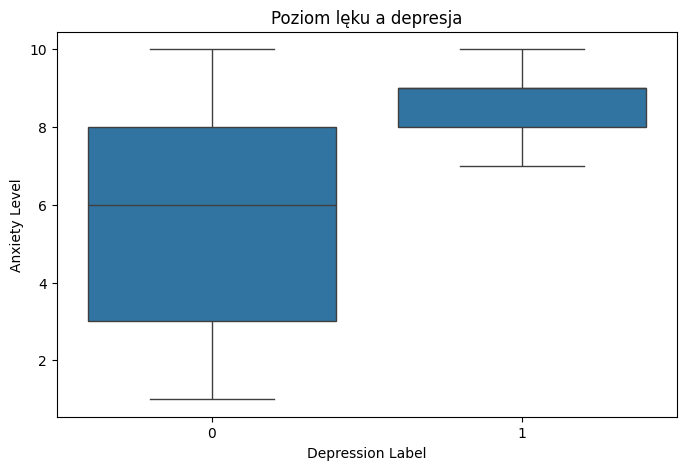

In [59]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="depression_label",
    y="anxiety_level",
    data=df
)

plt.title("Poziom lęku a depresja")

plt.xlabel("Depression Label")
plt.ylabel("Anxiety Level")

plt.show()

Osoby z depresją osiągają wyższe wartości poziomu lęku niż osoby bez depresji.

Może to sugerować silną zależność pomiędzy poziomem lęku a depresją.

# Analiza korzystania z platform społecznościowych

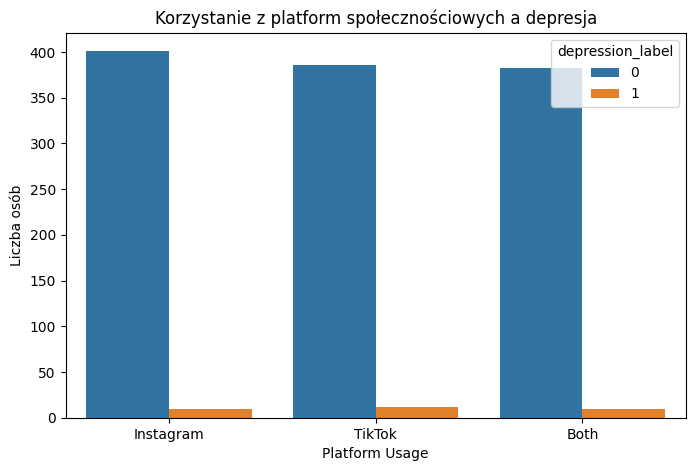

In [60]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="platform_usage",
    hue="depression_label",
    data=df
)

plt.title("Korzystanie z platform społecznościowych a depresja")

plt.xlabel("Platform Usage")
plt.ylabel("Liczba osób")

plt.show()

Wykres przedstawia zależność pomiędzy korzystaniem z platform społecznościowych a występowaniem depresji.

Dla każdej kategorii (`Instagram`, `TikTok`, `Both`) pokazano liczbę osób:
- bez depresji (0),
- z depresją (1).

Można zauważyć, że większość osób w każdej grupie nie wykazuje objawów depresji, co wynika z mocno niezbalansowanego zbioru danych.

Jednocześnie widoczne są niewielkie różnice pomiędzy grupami korzystającymi z różnych platform społecznościowych.

Największą liczbę przypadków depresji można zaobserwować w grupie korzystającej głównie z TikToka oraz wśród osób korzystających z obu platform jednocześnie.

Wyniki mogą sugerować istnienie zależności pomiędzy intensywnym korzystaniem z mediów społecznościowych a zdrowiem psychicznym nastolatków, jednak na podstawie samego wykresu nie można stwierdzić związku przyczynowo-skutkowego.



# Analiza korelacji

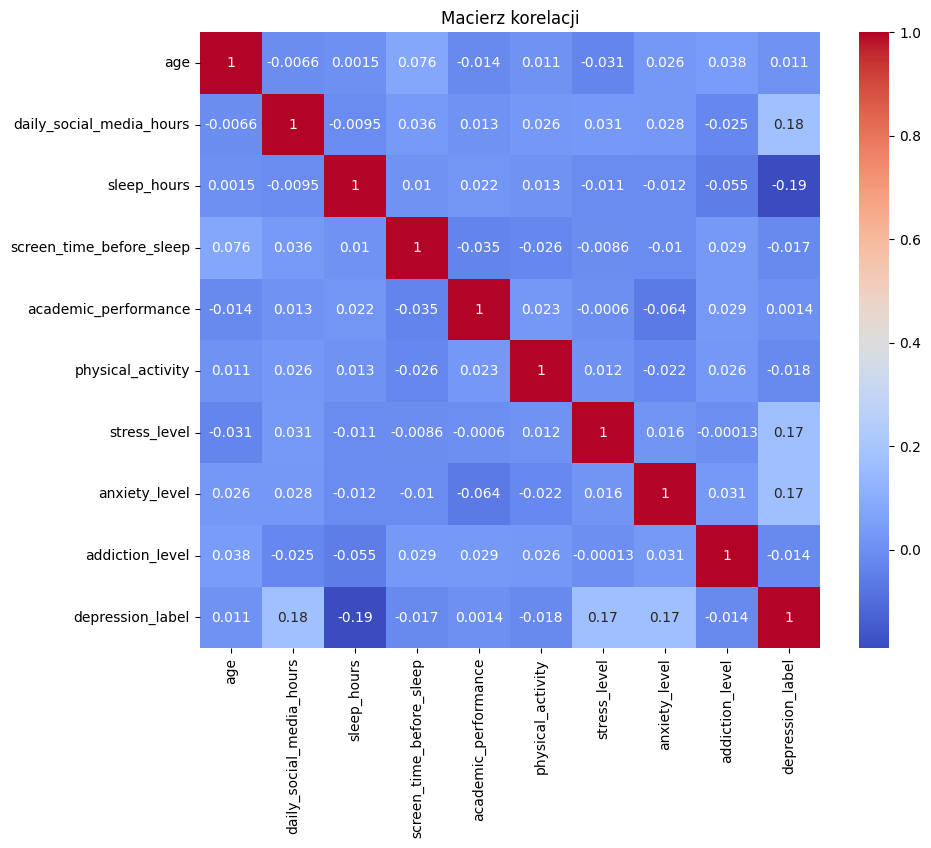

In [61]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Macierz korelacji")

plt.show()

Macierz korelacji pozwala zauważyć zależności pomiędzy zmiennymi numerycznymi.

Najsilniejsze zależności z depresją można zaobserwować dla:
- poziomu stresu,
- poziomu lęku,
- poziomu uzależnienia.

# Przygotowanie danych do uczenia maszynowego

In [62]:
X = df.drop("depression_label", axis=1)
y = df["depression_label"]

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Dane zostały podzielone na zbiór treningowy oraz testowy.

Wykorzystano parametr `stratify=y`, aby zachować proporcje klas w obu zbiorach.

In [64]:
num_cols = X.select_dtypes(include=np.number).columns

cat_cols = X.select_dtypes(exclude=np.number).columns

print("Kolumny numeryczne:")
print(num_cols)

print("\nKolumny kategoryczne:")
print(cat_cols)

Kolumny numeryczne:
Index(['age', 'daily_social_media_hours', 'sleep_hours',
       'screen_time_before_sleep', 'academic_performance', 'physical_activity',
       'stress_level', 'anxiety_level', 'addiction_level'],
      dtype='object')

Kolumny kategoryczne:
Index(['gender', 'platform_usage', 'social_interaction_level'], dtype='object')


# Pipeline preprocessingu danych

In [65]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [66]:
from sklearn.preprocessing import OneHotEncoder

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

Dane numeryczne zostały przeskalowane przy użyciu `StandardScaler`, natomiast dane tekstowe zostały zakodowane za pomocą `OneHotEncoder`.

# Model Logistic Regression

In [67]:
log_reg = Pipeline([
    ("prep", full_pipeline),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

log_reg.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'daily_social_media_hours', 'sleep_hours',
       'screen_time_before_sleep', 'academic_performance', 'physical_activity',
       'stress_level', 'anxiety_level', 'addiction_level'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'platform_usage', 'social_interaction_level'], dtype='object'))])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [68]:
y_pred_log = log_reg.predict(X_test)

In [69]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       234
           1       0.50      0.83      0.62         6

    accuracy                           0.97       240
   macro avg       0.75      0.91      0.81       240
weighted avg       0.98      0.97      0.98       240



In [70]:
log_acc = accuracy_score(y_test, y_pred_log)

print(log_acc)

0.975


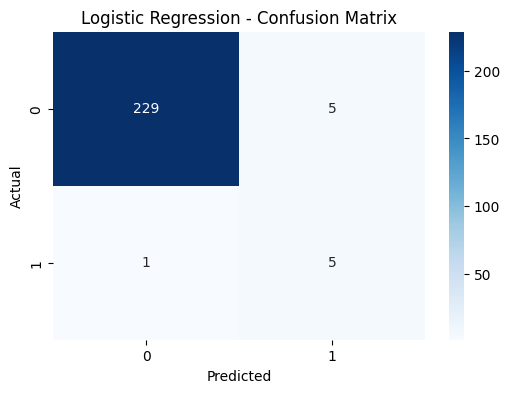

In [71]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

Model Logistic Regression osiągnął wysoką wartość recall dla klasy pozytywnej, dzięki czemu poprawnie wykrywał większość przypadków depresji.

# Model Random Forest

In [72]:
forest = Pipeline([
    ("prep", full_pipeline),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

**Trenowanie**

In [73]:
forest.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'daily_social_media_hours', 'sleep_hours',
       'screen_time_before_sleep', 'academic_performance', 'physical_activity',
       'stress_level', 'anxiety_level', 'addiction_level'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'platform_usage', 'social_interaction_level'], dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

predykcja

In [74]:
y_pred_forest = forest.predict(X_test)

**raport**

In [75]:
print(classification_report(y_test, y_pred_forest))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       234
           1       1.00      0.33      0.50         6

    accuracy                           0.98       240
   macro avg       0.99      0.67      0.75       240
weighted avg       0.98      0.98      0.98       240



In [76]:
forest_acc = accuracy_score(y_test, y_pred_forest)

print(forest_acc)

0.9833333333333333


Confusion matrix

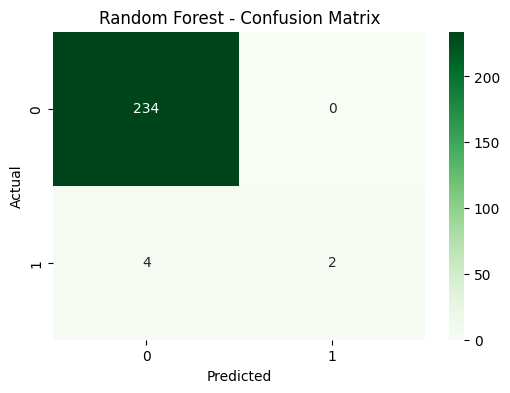

In [77]:
cm = confusion_matrix(y_test, y_pred_forest)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")

plt.show()

Model Random Forest osiągnął bardzo wysoką accuracy, jednak wykrywał mniej przypadków depresji niż Logistic Regression.

# Optymalizacja hiperparametrów modelu Random Forest

In [78]:
param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [5, 10]
}

In [79]:
grid_search = GridSearchCV(
    forest,
    param_grid,
    cv=3,
    scoring="f1"
)

In [80]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['age', 'daily_social_media_hours', 'sleep_hours',
       'screen_time_before_sleep', 'academic_performance', 'physical_activity',
       'stress_level', 'anxiety_level', 'addiction_level'],
      dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['gender', 'platform_usage', 'social_interaction_level'], dtype='object'))])),
                                       ('model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               random_state=42))]),
             param_grid={'model__max_depth': [5, 10],
                         'model__n_estimators': [50, 100]},
             scoring='f1')

In [81]:
print(grid_search.best_params_)

{'model__max_depth': 5, 'model__n_estimators': 50}


In [83]:
print(grid_search.best_score_)

0.8634920634920634


Przeprowadzono prostą optymalizację hiperparametrów modelu Random Forest przy użyciu GridSearchCV.

Najlepsze parametry zostały wybrane na podstawie wartości F1-score.

# Porównanie modeli

In [82]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Recall": [
        0.83,
        0.33
    ],
    "F1-Score": [
        0.62,
        0.50
    ]
})

comparison

,Model,Recall,F1-Score
0,Logistic Regression,0.83,0.62
1,Random Forest,0.33,0.50


# Wnioski

W projekcie przeanalizowano zależności pomiędzy zdrowiem psychicznym nastolatków a różnymi czynnikami, takimi jak:
- stres,
- sen,
- poziom lęku,
- korzystanie z platform społecznościowych.

Analiza danych pokazała, że osoby z depresją osiągały wyższe poziomy stresu i lęku oraz spały mniej godzin.

Następnie zaimplementowano dwa modele uczenia maszynowego:
- Logistic Regression,
- Random Forest Classifier.

Ze względu na mocno niezbalansowany zbiór danych najważniejszymi metrykami były recall oraz F1-score.

Lepsze wyniki osiągnął model Logistic Regression, który skuteczniej wykrywał przypadki depresji.